# Compare predictive performance across endpoint categories

How does predictive performance compare across endpoint types?

In [1]:
import polars as pl 
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import MultiComparison
import warnings

## Input annotations

In [2]:
endpoint_types = ["toxcast_cellbased", "toxcast_cellfree", "toxcast_cytotox", "axiom"]

pred_df = []
for et in endpoint_types:
    preds = pl.read_parquet(f"../compiled_results/compiled_{et}_metrics.parquet")
    preds = preds.with_columns(
        (pl.col("Metadata_Count_0") + pl.col("Metadata_Count_1")).alias("Total_Compounds"),
        pl.lit(et).alias("Endpoint_type")
    )
    pred_df.append(preds)

pred_df = pl.concat(pred_df, how="vertical")
pred_df = pred_df.with_columns(
    pl.when(pl.col("Endpoint_type") == "axiom").then(pl.lit("axiom_cytotox")).otherwise(pl.col("Endpoint_type")).alias("Endpoint_type"),
    (pl.col("Metadata_Count_1")/pl.col("Total_Compounds")).alias("Percent_Positive"),
)

pred_pandas = pred_df.to_pandas()
pred_pandas['Endpoint_type'] = pd.Categorical(
    pred_pandas['Endpoint_type'], 
    categories=["axiom_cytotox", "toxcast_cytotox", "toxcast_cellbased", "toxcast_cellfree"],
    ordered=True
)


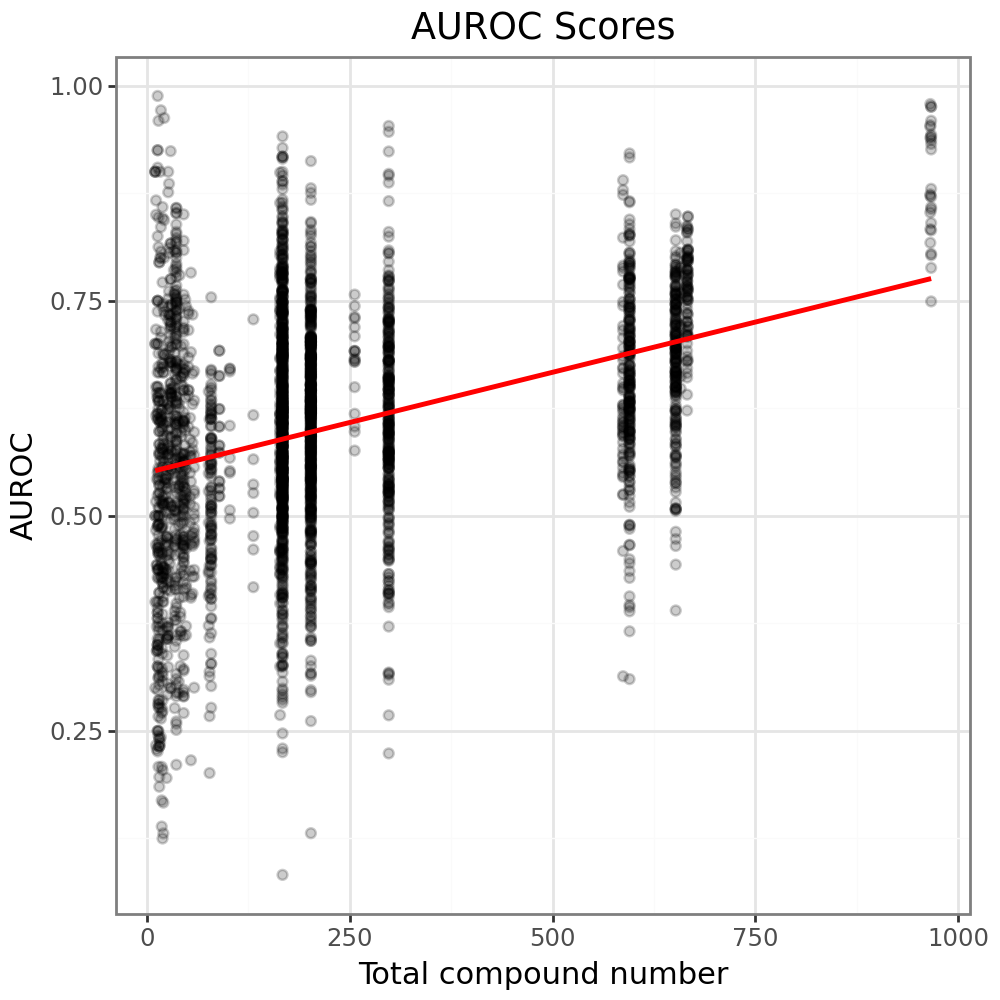

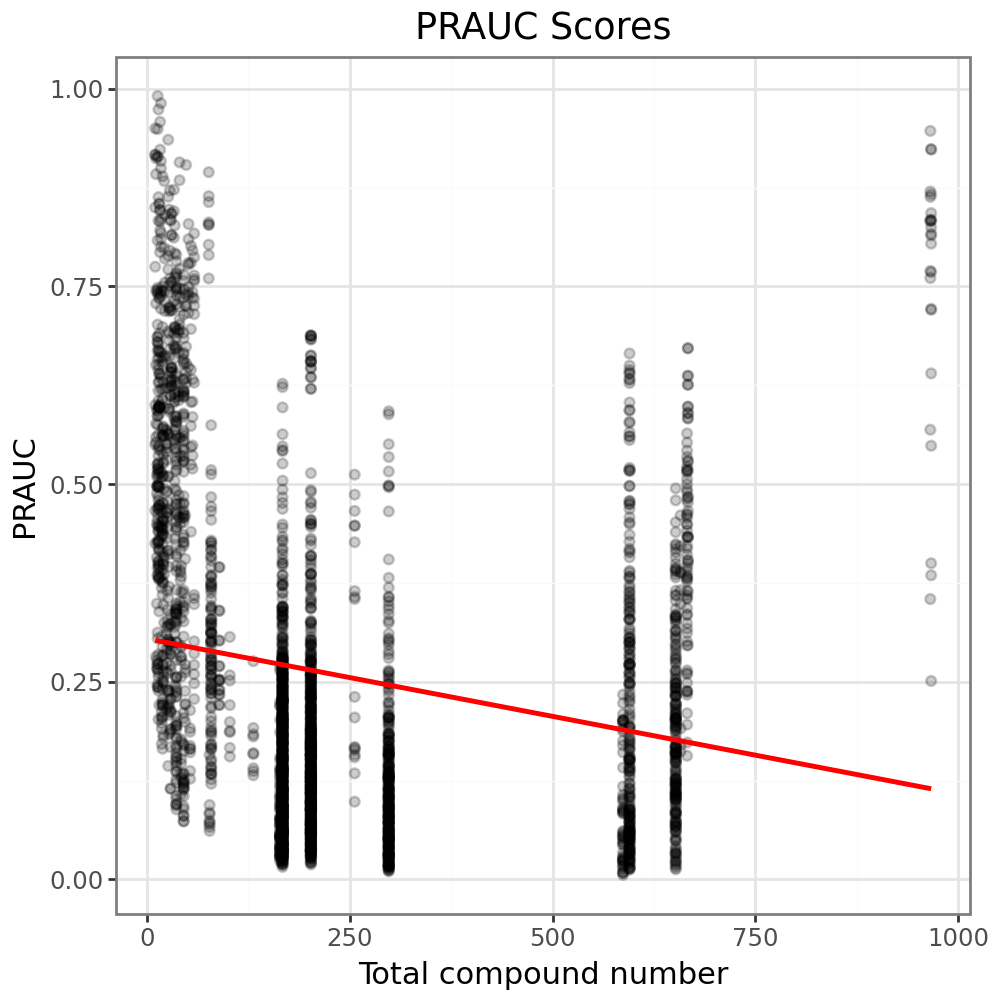

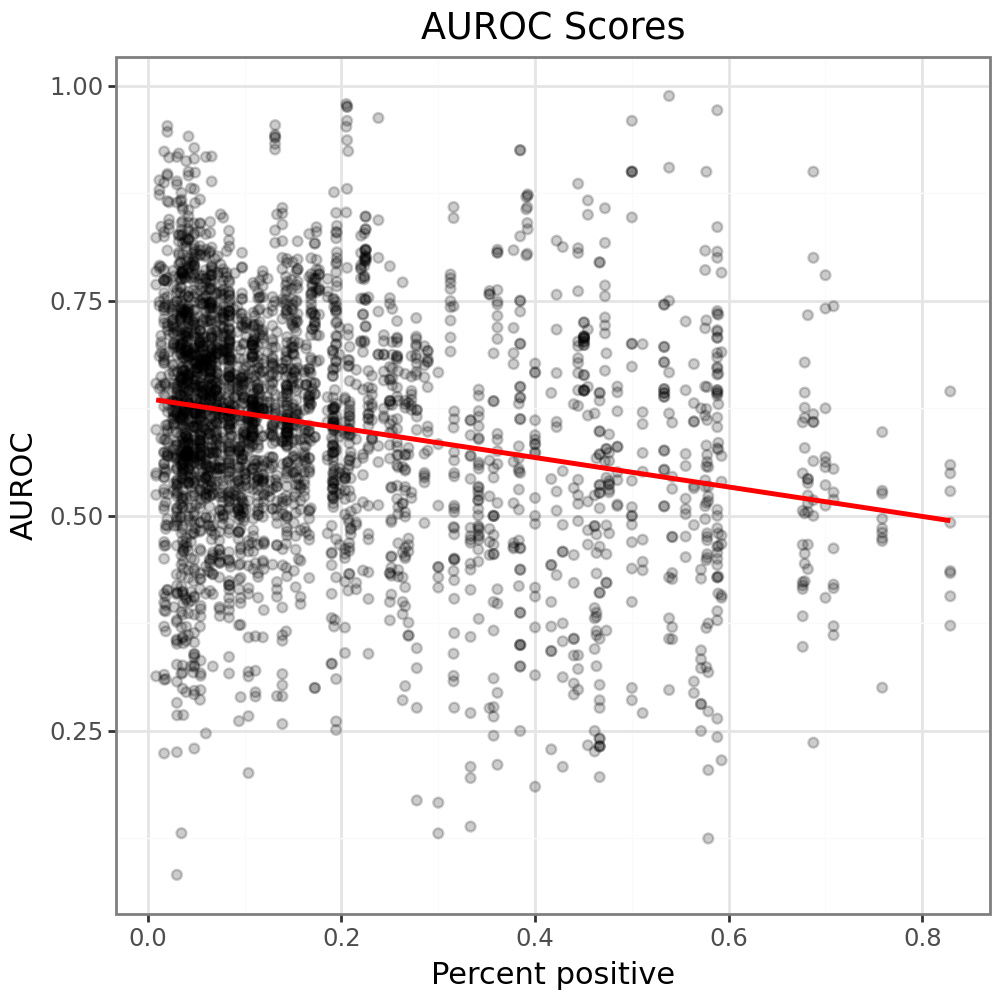

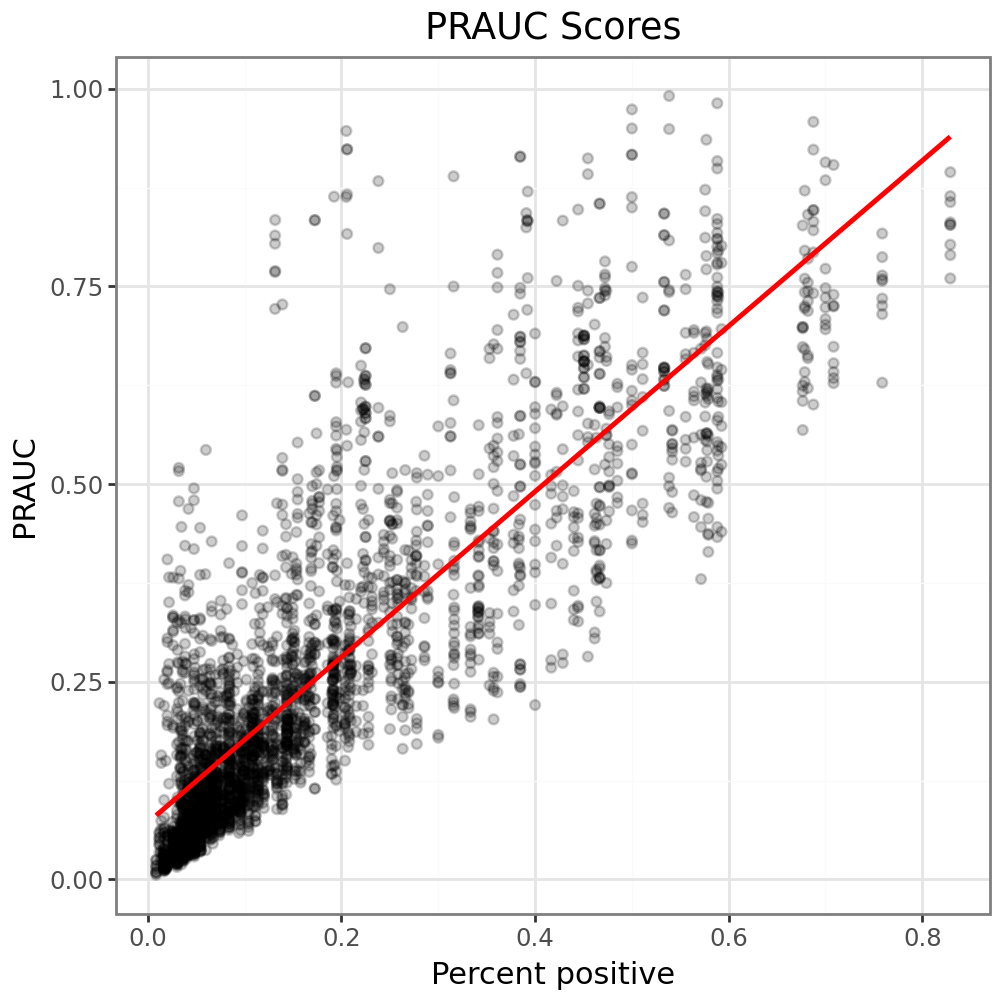

In [3]:
import plotnine as pn
from plotnine import geom_point, ggplot, aes, labs, theme_bw, facet_wrap, geom_smooth

pn.options.figure_size = (5, 5)

plot = (
    ggplot(pred_pandas[pred_pandas["Model_type"] == "Actual"], aes(x='Total_Compounds', y='AUROC')) 
    + geom_point(alpha=0.2) 
    + geom_smooth(method='lm', color='red', se=False)
    + labs(title='AUROC Scores', x='Total compound number', y='AUROC') 
    + theme_bw()
)
plot.show()

plot = (
    ggplot(pred_pandas[pred_pandas["Model_type"] == "Actual"], aes(x='Total_Compounds', y='PRAUC')) 
    + geom_point(alpha=0.2) 
    + geom_smooth(method='lm', color='red', se=False)
    + labs(title='PRAUC Scores', x='Total compound number', y='PRAUC') 
    + theme_bw()
)
plot.show()

plot = (
    ggplot(pred_pandas[pred_pandas["Model_type"] == "Actual"], aes(x='Percent_Positive', y='AUROC')) 
    + geom_point(alpha=0.2) 
    + geom_smooth(method='lm', color='red', se=False)
    + labs(title='AUROC Scores', x='Percent positive', y='AUROC') 
    + theme_bw()
)
plot.show()

plot = (
    ggplot(pred_pandas[pred_pandas["Model_type"] == "Actual"], aes(x='Percent_Positive', y='PRAUC')) 
    + geom_point(alpha=0.2) 
    + geom_smooth(method='lm', color='red', se=False)
    + labs(title='PRAUC Scores', x='Percent positive', y='PRAUC') 
    + theme_bw()
)
plot.show()

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


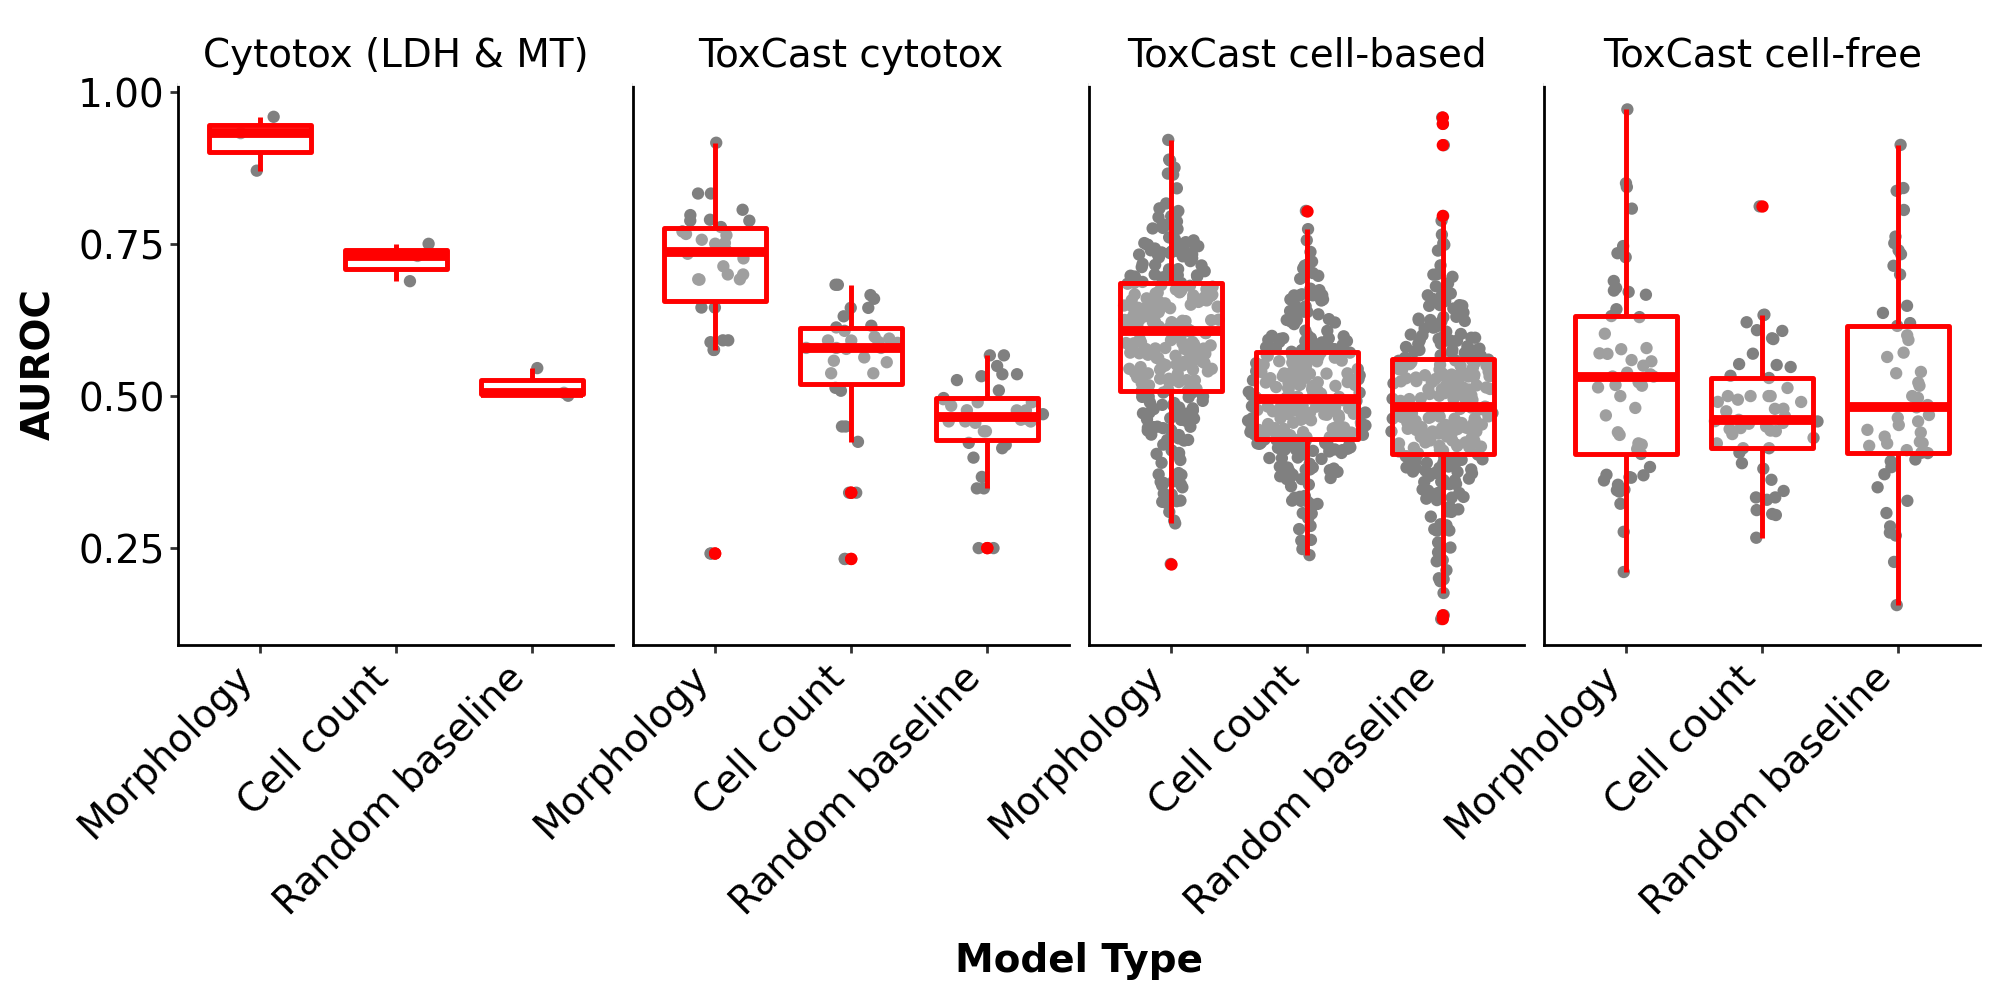

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


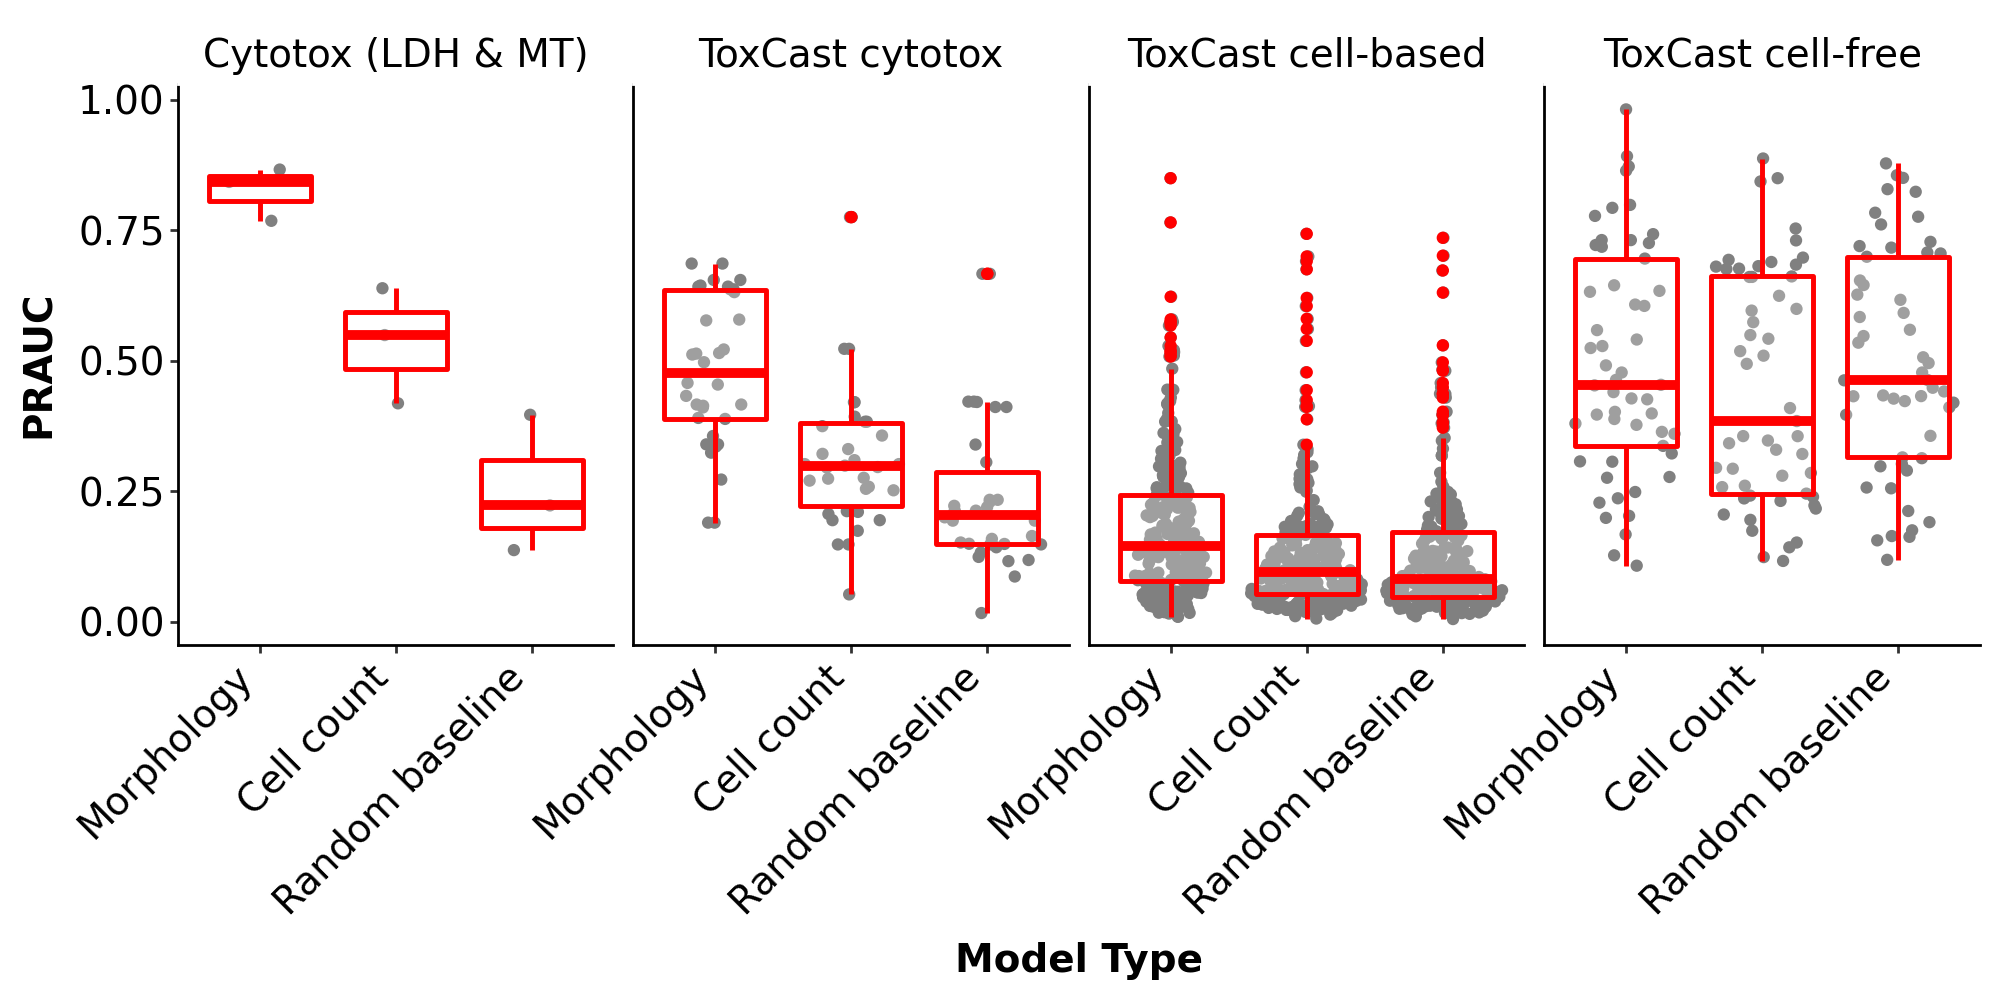

In [4]:
from plotnine import ggplot, aes, geom_sina, geom_boxplot, labs, theme_classic, position_dodge, facet_wrap, theme, element_text, scale_x_discrete, element_rect
import plotnine as pn

pn.options.figure_size = (10, 5)

custom_labels = {
    "axiom_cytotox": "Cytotox (LDH & MT)",
    "toxcast_cytotox": "ToxCast cytotox",
    "toxcast_cellbased": "ToxCast cell-based",
    "toxcast_cellfree": "ToxCast cell-free",
}
def label_func(label_dict):
    return lambda x: label_dict.get(x, x)

pred_pandas = pred_df.filter(pl.col("Metadata_AggType") == "all").filter(pl.col("Feat_type") == "cellprofiler").to_pandas()
pred_pandas['Endpoint_type'] = pd.Categorical(
    pred_pandas['Endpoint_type'], 
    categories=["axiom_cytotox", "toxcast_cytotox", "toxcast_cellbased", "toxcast_cellfree"],
    ordered=True
)

plot = (
    ggplot(pred_pandas, aes(x='Model_type', y='AUROC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Model Type', y='AUROC') 
    + theme_classic()
    + theme(
        axis_text_x=element_text(angle=45, hjust=1, color='black', size=14, family='Arial'),
        axis_text_y=element_text(color='black', size=14, family='Arial'),
        axis_title_x=element_text(size=14, color='black', weight='bold', family='Arial'),
        axis_title_y=element_text(size=14, color='black', weight='bold', family='Arial'),
        strip_text_x=element_text(size=14, color='black', family='Arial'),
        strip_background=element_rect(fill=None, color='white', size=None, linetype=None),
        )
    + scale_x_discrete(labels={
        "Actual": "Morphology", 
        "Cellcount_baseline": "Cell count", 
        "Random_baseline": "Random baseline"
    })
)
plot.show()

plot = (
    ggplot(pred_pandas, aes(x='Model_type', y='PRAUC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Model Type', y='PRAUC') 
    + theme_classic()
    + theme(
        axis_text_x=element_text(angle=45, hjust=1, color='black', size=14, family='Arial'),
        axis_text_y=element_text(color='black', size=14, family='Arial'),
        axis_title_x=element_text(size=14, color='black', weight='bold', family='Arial'),
        axis_title_y=element_text(size=14, color='black', weight='bold', family='Arial'),
        strip_text_x=element_text(size=14, color='black', family='Arial'),
        strip_background=element_rect(fill=None, color='white', size=None, linetype=None),
        )
    + scale_x_discrete(labels={
        "Actual": "Morphology", 
        "Cellcount_baseline": "Cell count", 
        "Random_baseline": "Random baseline"
    })
)
plot.show()

Endpoint rows before mixed-effects modeling: {'axiom_cytotox': 9, 'toxcast_cytotox': 69, 'toxcast_cellbased': 696, 'toxcast_cellfree': 6}


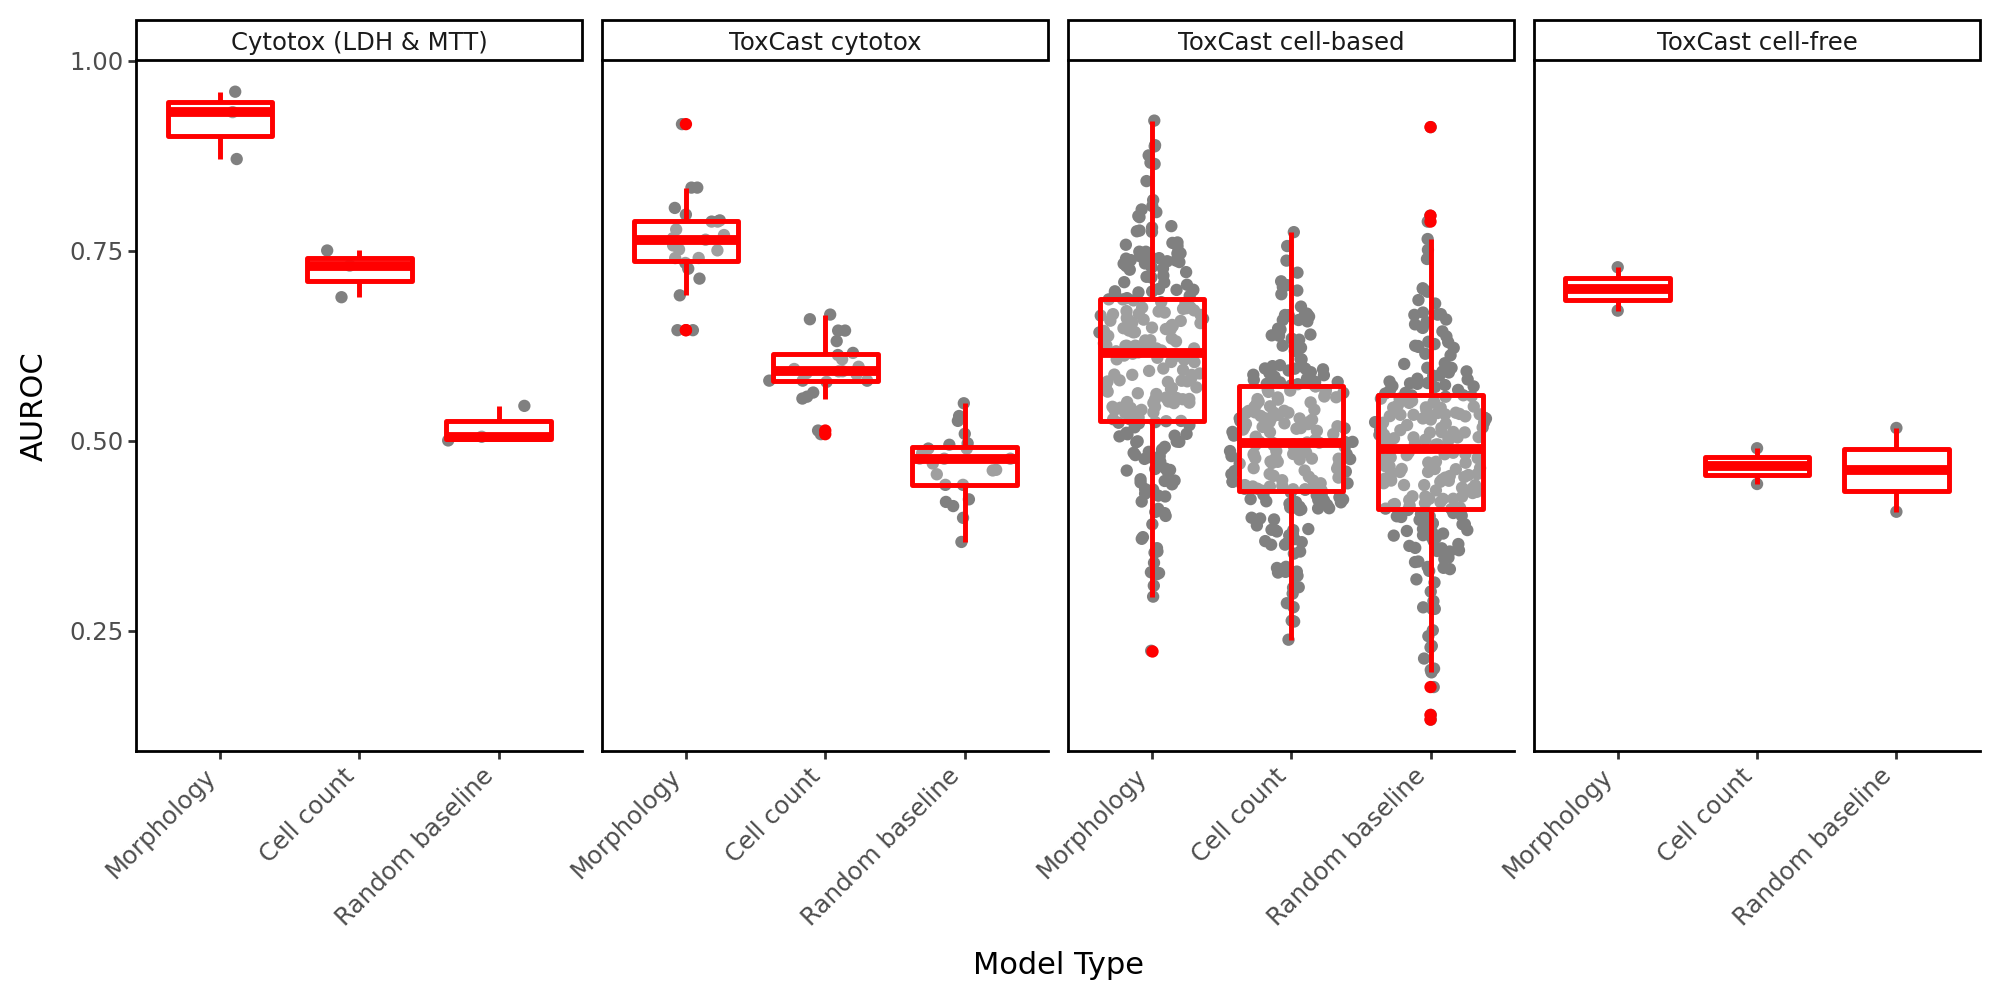

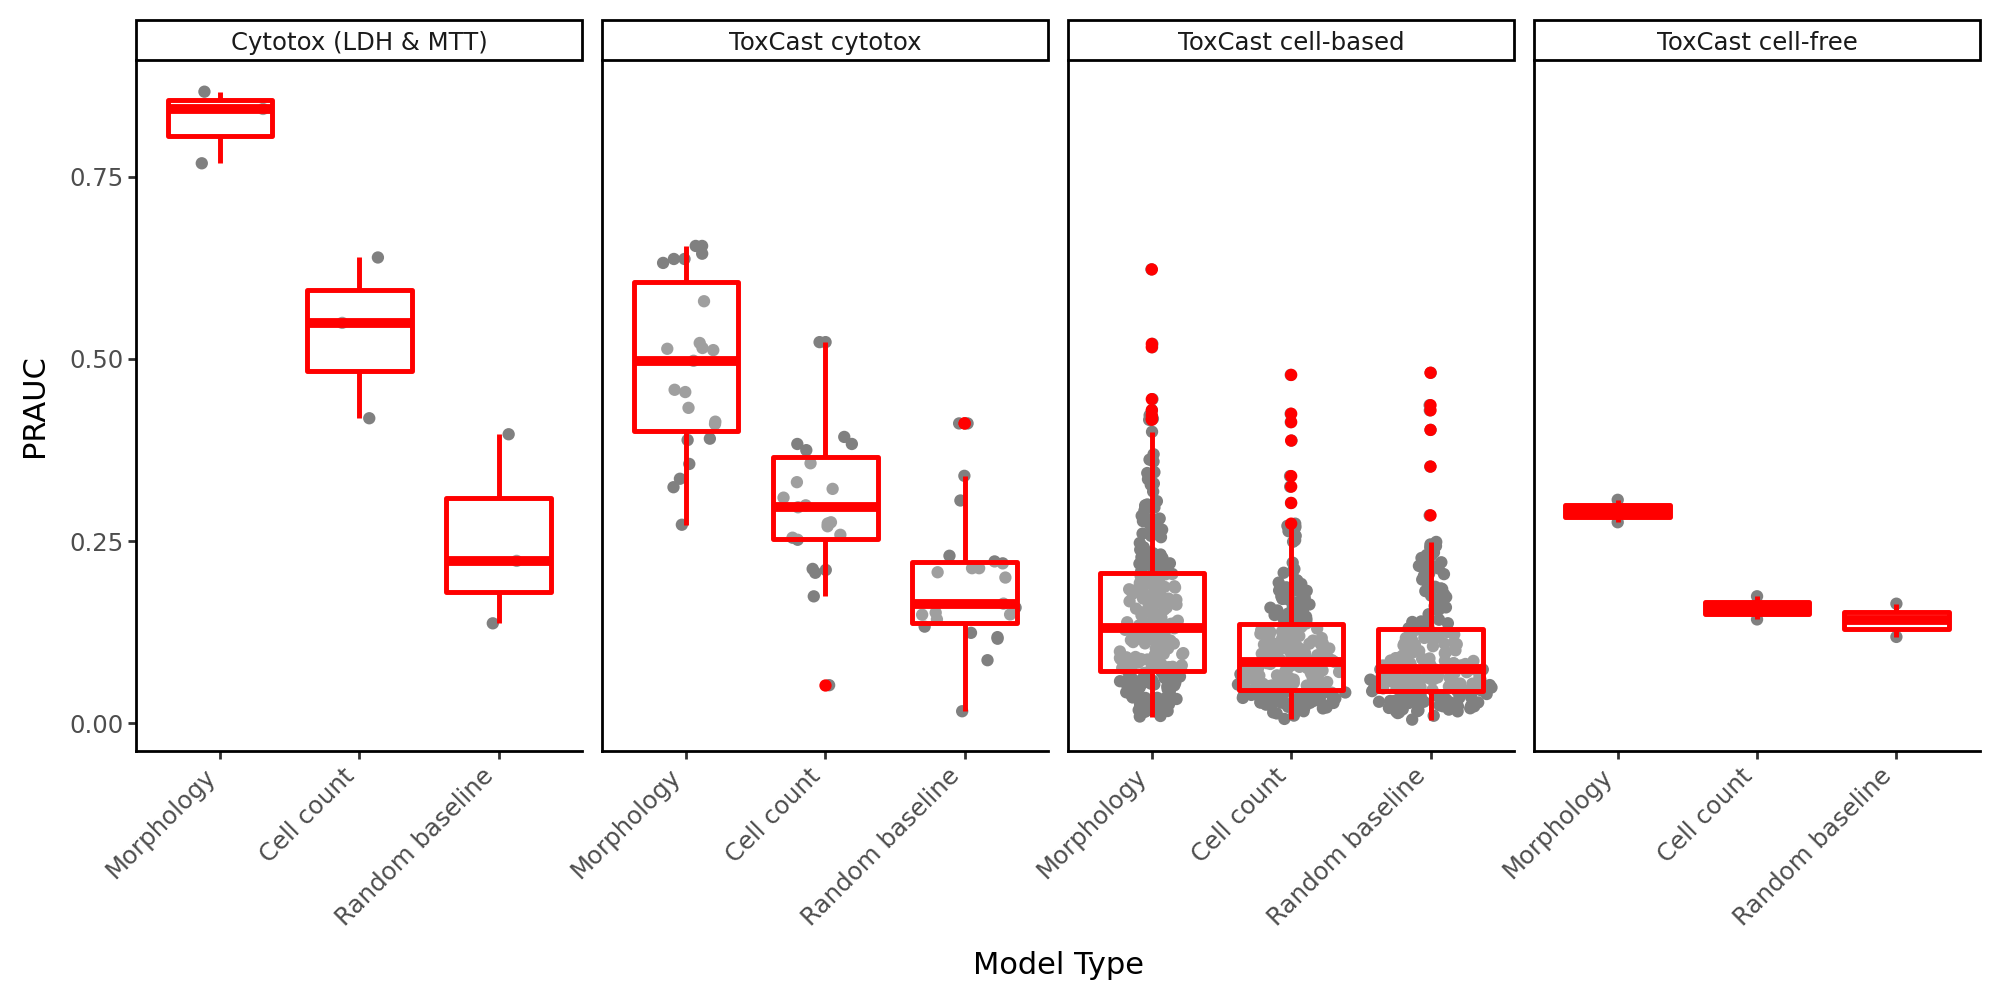

In [5]:
from plotnine import ggplot, aes, geom_sina, geom_boxplot, labs, theme_classic, position_dodge, facet_wrap, theme, element_text, scale_x_discrete
import plotnine as pn

pn.options.figure_size = (10, 5)

custom_labels = {
    "axiom_cytotox": "Cytotox (LDH & MTT)",
    "toxcast_cytotox": "ToxCast cytotox",
    "toxcast_cellbased": "ToxCast cell-based",
    "toxcast_cellfree": "ToxCast cell-free",
}
def label_func(label_dict):
    return lambda x: label_dict.get(x, x)

expected_endpoint_types = [
    "axiom_cytotox",
    "toxcast_cytotox",
    "toxcast_cellbased",
    "toxcast_cellfree",
]

pred_pandas = (
    pred_df.filter(pl.col("Metadata_AggType") == "all")
    .filter(pl.col("Feat_type") == "cellprofiler")
    .filter(pl.col("Total_Compounds") >= 100)
    .to_pandas()
)
pred_pandas['Endpoint_type'] = pd.Categorical(
    pred_pandas['Endpoint_type'], 
    categories=expected_endpoint_types,
    ordered=True
)

endpoint_type_counts = pred_pandas.groupby(
    "Endpoint_type", observed=True
).size().to_dict()
print("Endpoint rows before mixed-effects modeling:", endpoint_type_counts)
assert set(endpoint_type_counts) == set(expected_endpoint_types), (
    "Expected four nonempty endpoint categories before mixed-effects modeling; "
    f"observed {endpoint_type_counts}"
)

pn.options.figure_size = (10, 5)

plot = (
    ggplot(pred_pandas, aes(x='Model_type', y='AUROC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Model Type', y='AUROC') 
    + theme_classic()
    + theme(axis_text_x=element_text(angle=45, hjust=1))
    + scale_x_discrete(labels={
        "Actual": "Morphology", 
        "Cellcount_baseline": "Cell count", 
        "Random_baseline": "Random baseline"
    })
)
plot.show()

plot = (
    ggplot(pred_pandas, aes(x='Model_type', y='PRAUC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Model Type', y='PRAUC') 
    + theme_classic()
    + theme(axis_text_x=element_text(angle=45, hjust=1))
    + scale_x_discrete(labels={
        "Actual": "Morphology", 
        "Cellcount_baseline": "Cell count", 
        "Random_baseline": "Random baseline"
    })
)
plot.show()

In [6]:
warnings.filterwarnings("ignore")

auroc_results = {}

for endpoint_type, group_data in pred_pandas.groupby("Endpoint_type", observed=True):
    print(f"Processing Endpoint_type: {endpoint_type}")
    
    # Fit the mixed-effects model
    model = smf.mixedlm(
        "AUROC ~ Model_type", 
        group_data, 
        groups=group_data["Metadata_Label"]
    )
    result = model.fit()
    print(f"MixedLM converged: {result.converged}")
    
    # Add fitted values to the subset DataFrame
    group_data["fitted_values"] = result.fittedvalues

    # Perform Tukey's HSD
    mc = MultiComparison(group_data["fitted_values"], group_data["Model_type"])
    tukey_result = mc.tukeyhsd()
    tukey_pvals = tukey_result.pvalues
    
    # Print results for the current Endpoint_type
    print(tukey_result.summary())
    print("P-values:", tukey_pvals)
    
    # Save results for each Endpoint_type in a dictionary for later reference
    auroc_results[endpoint_type] = {
        "tukey_summary": tukey_result.summary(),
        "tukey_pvalues": tukey_pvals,
        "fitted_model": result
    }

Processing Endpoint_type: axiom_cytotox
MixedLM converged: True
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
            Actual Cellcount_baseline  -0.1975 0.0004 -0.2687 -0.1263   True
            Actual    Random_baseline  -0.4035    0.0 -0.4747 -0.3322   True
Cellcount_baseline    Random_baseline  -0.2059 0.0003 -0.2772 -0.1347   True
----------------------------------------------------------------------------
P-values: [3.53965400e-04 5.76410368e-06 2.80361023e-04]
Processing Endpoint_type: toxcast_cytotox
MixedLM converged: True
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1             group2       meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------
            Actual Cellcount_baseline  -0.1687

MixedLM converged: True
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1             group2       meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------
            Actual Cellcount_baseline  -0.1026   0.0 -0.1048 -0.1005   True
            Actual    Random_baseline  -0.1187   0.0 -0.1209 -0.1166   True
Cellcount_baseline    Random_baseline  -0.0161   0.0 -0.0182  -0.014   True
---------------------------------------------------------------------------
P-values: [3.21964677e-13 3.21964677e-13 3.21964677e-13]
Processing Endpoint_type: toxcast_cellfree
MixedLM converged: True
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1             group2       meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------
            Actual Cellcount_baseline   -0.233   0.0  -0.233  -0.233   True
            Actu

In [7]:
warnings.filterwarnings("ignore")

prauc_results = {}

for endpoint_type, group_data in pred_pandas.groupby("Endpoint_type", observed=True):
    print(f"Processing Endpoint_type: {endpoint_type}")
    
    # Fit the mixed-effects model
    model = smf.mixedlm(
        "PRAUC ~ Model_type", 
        group_data, 
        groups=group_data["Metadata_Label"]
    )
    result = model.fit()
    print(f"MixedLM converged: {result.converged}")
    
    # Add fitted values to the subset DataFrame
    group_data["fitted_values"] = result.fittedvalues

    # Perform Tukey's HSD
    mc = MultiComparison(group_data["fitted_values"], group_data["Model_type"])
    tukey_result = mc.tukeyhsd()
    tukey_pvals = tukey_result.pvalues
    
    # Print results for the current Endpoint_type
    print(tukey_result.summary())
    print("P-values:", tukey_pvals)
    
    # Save results for each Endpoint_type in a dictionary for later reference
    prauc_results[endpoint_type] = {
        "tukey_summary": tukey_result.summary(),
        "tukey_pvalues": tukey_pvals,
        "fitted_model": result
    }

Processing Endpoint_type: axiom_cytotox
MixedLM converged: True


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
            Actual Cellcount_baseline  -0.2902 0.0108 -0.4926 -0.0879   True
            Actual    Random_baseline  -0.5737 0.0003 -0.7761 -0.3713   True
Cellcount_baseline    Random_baseline  -0.2835 0.0121 -0.4858 -0.0811   True
----------------------------------------------------------------------------
P-values: [0.01083467 0.00031333 0.01208822]
Processing Endpoint_type: toxcast_cytotox
MixedLM converged: True
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
            Actual Cellcount_baseline  -0.1869    0.0 -0.2552 -0.1187   True
            Actual    Random_baseline  -0.

MixedLM converged: True
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
            Actual Cellcount_baseline  -0.0499    0.0 -0.0634 -0.0364   True
            Actual    Random_baseline  -0.0548    0.0 -0.0683 -0.0413   True
Cellcount_baseline    Random_baseline  -0.0049 0.6743 -0.0183  0.0086  False
----------------------------------------------------------------------------
P-values: [3.22075699e-13 3.21964677e-13 6.74292210e-01]
Processing Endpoint_type: toxcast_cellfree
MixedLM converged: False
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
            Actual Cellcount_baseline  -0.1328    0.0 -0.1353 -0.1303   True
    

## Redo after filtering by compound number

In [8]:
pred_df = pred_df.filter(pl.col("Total_Compounds") >= 100)
pred_pandas = pred_df.to_pandas()
pred_pandas['Endpoint_type'] = pd.Categorical(
    pred_pandas['Endpoint_type'], 
    categories=["axiom_cytotox", "toxcast_cytotox", "toxcast_cellbased", "toxcast_cellfree"],
    ordered=True
)

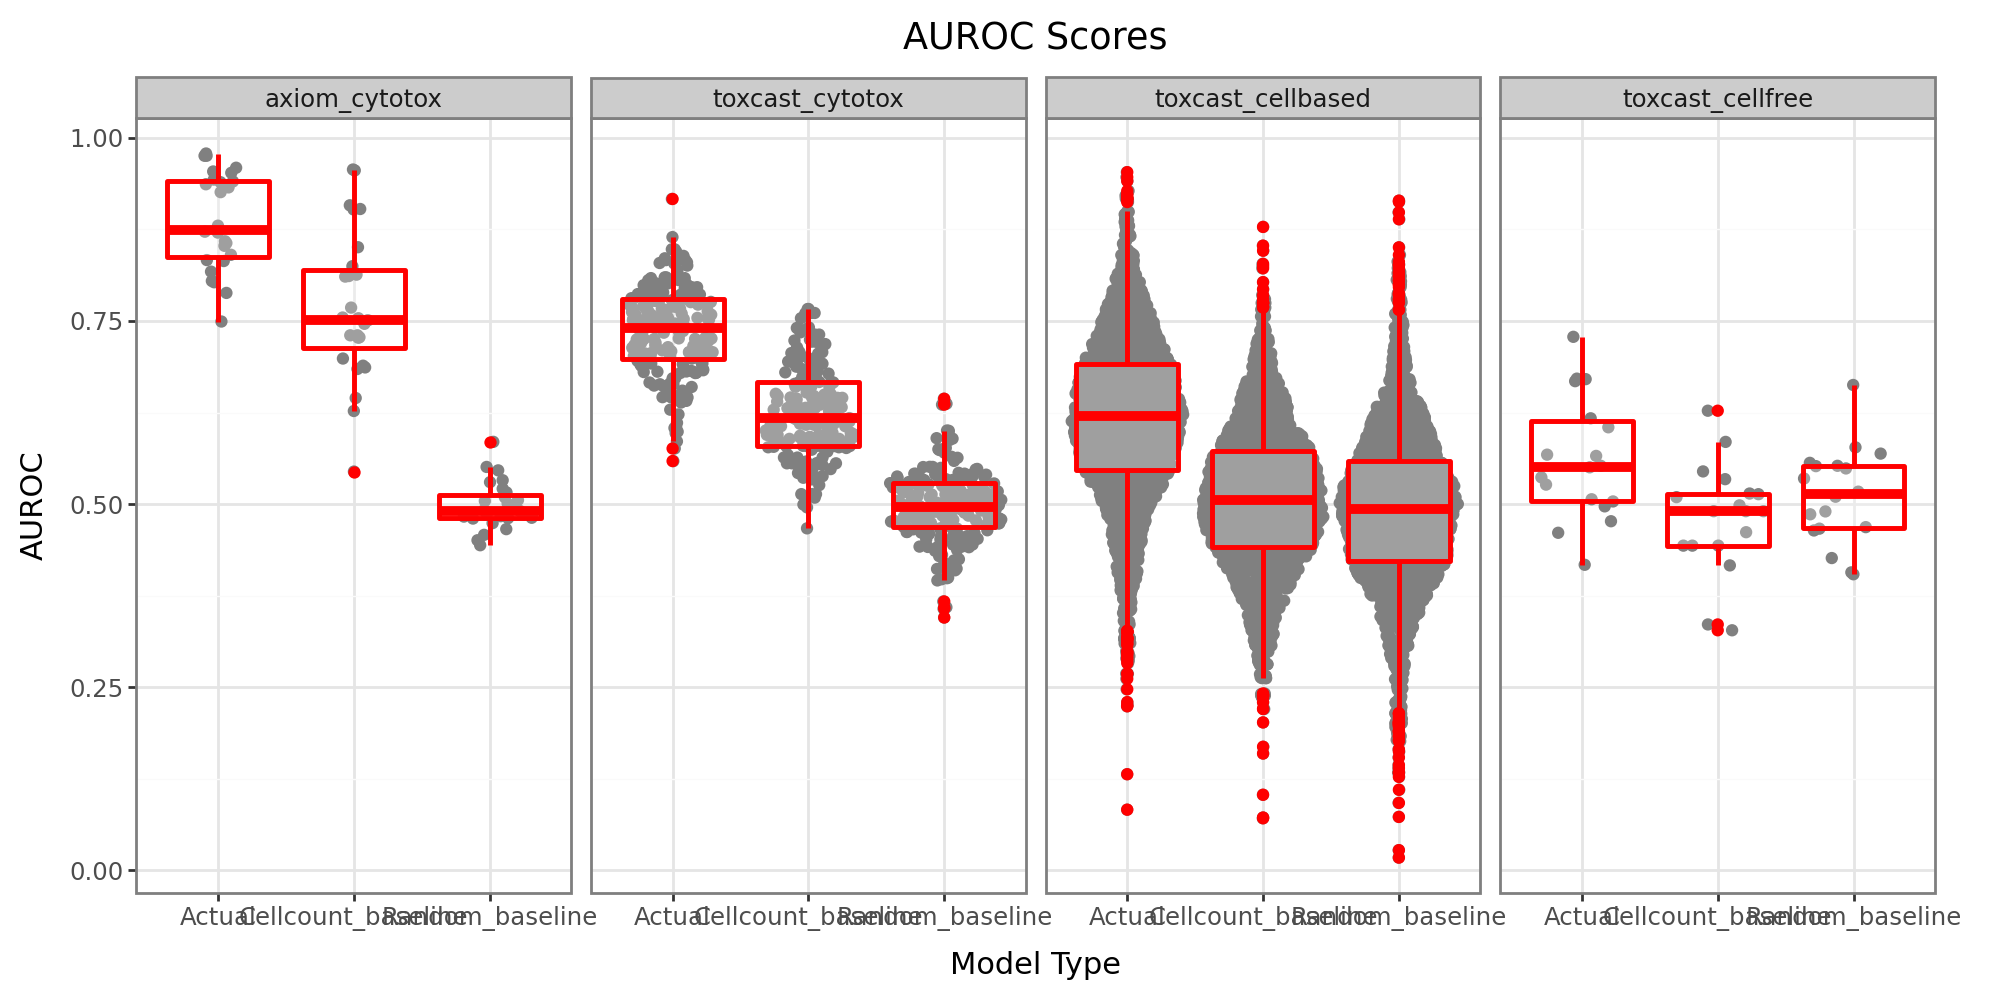

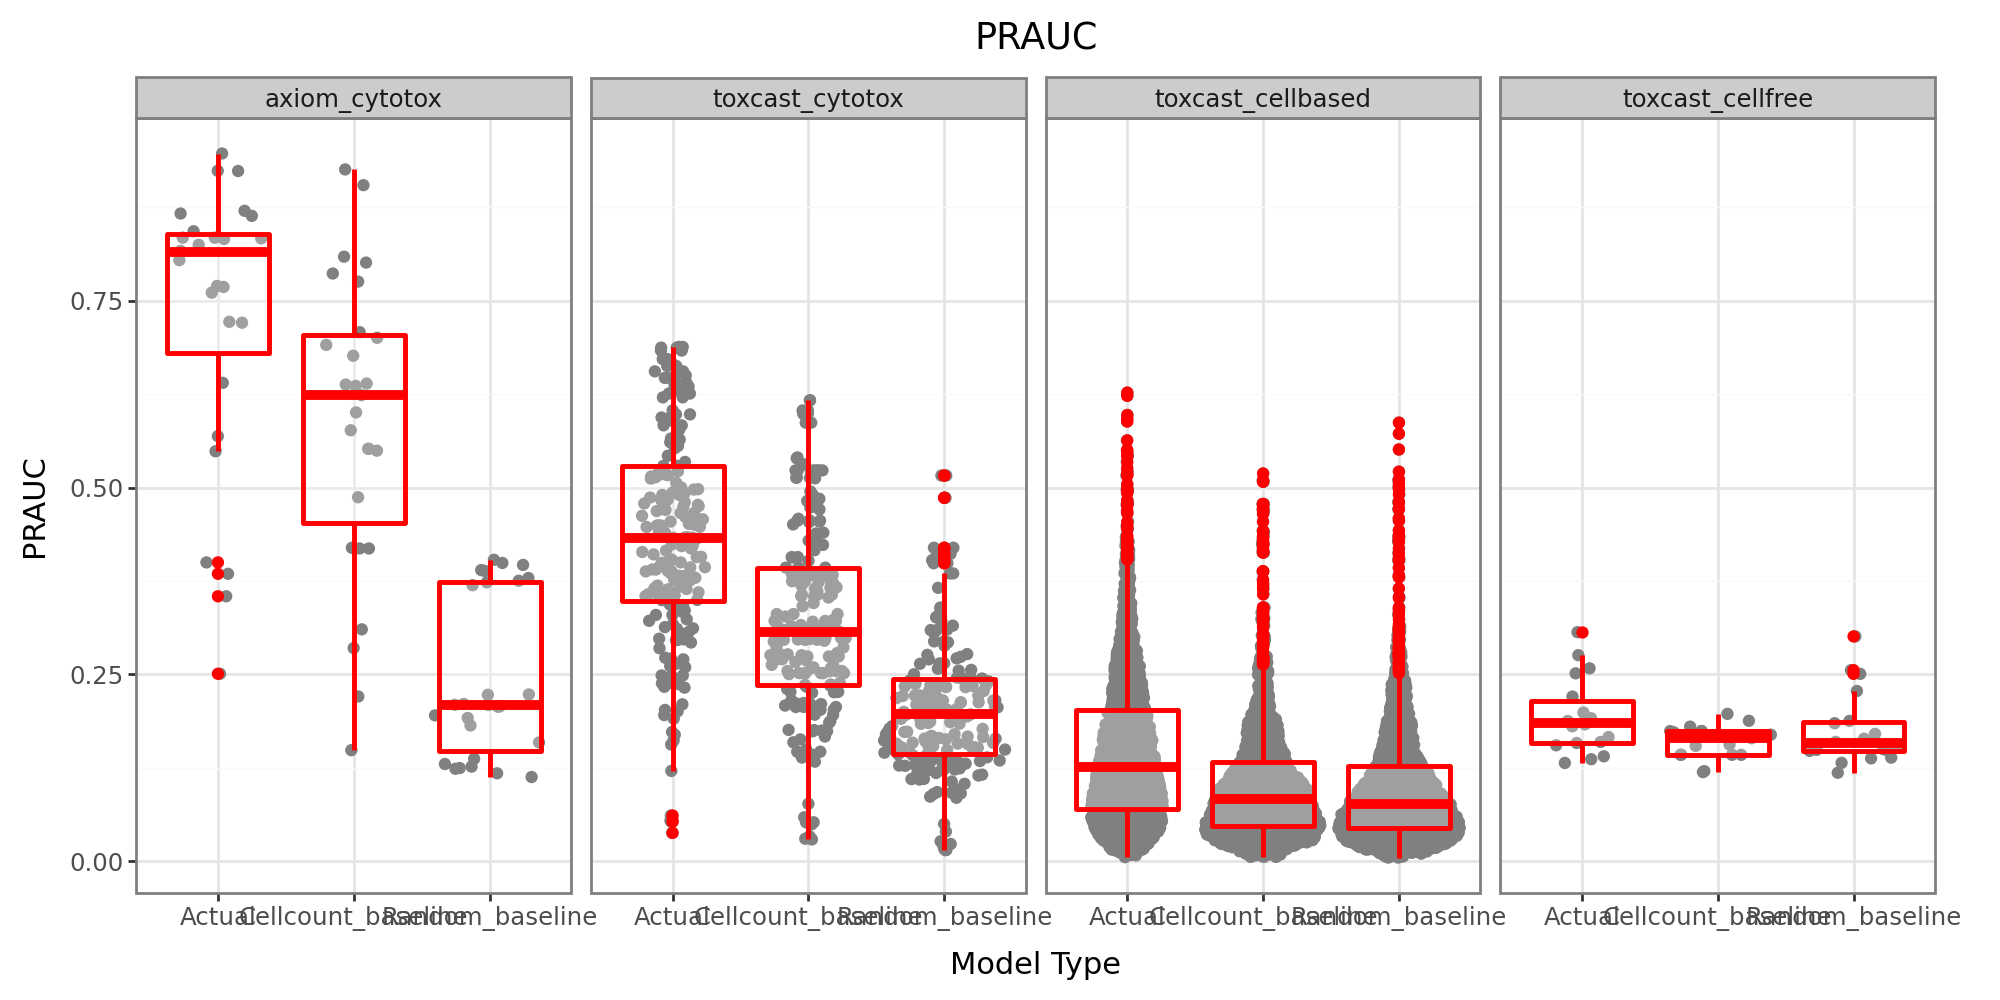

In [9]:
from plotnine import ggplot, aes, geom_sina, geom_boxplot, labs, theme_bw, position_dodge, facet_wrap
import plotnine as pn

pn.options.figure_size = (10, 5)

plot = (
    ggplot(pred_pandas, aes(x='Model_type', y='AUROC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=5)
    + labs(title='AUROC Scores', x='Model Type', y='AUROC') 
    + theme_bw()
)
plot.show()

plot = (
    ggplot(pred_pandas, aes(x='Model_type', y='PRAUC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=5)
    + labs(title='PRAUC', x='Model Type', y='PRAUC') 
    + theme_bw()
)
plot.show()

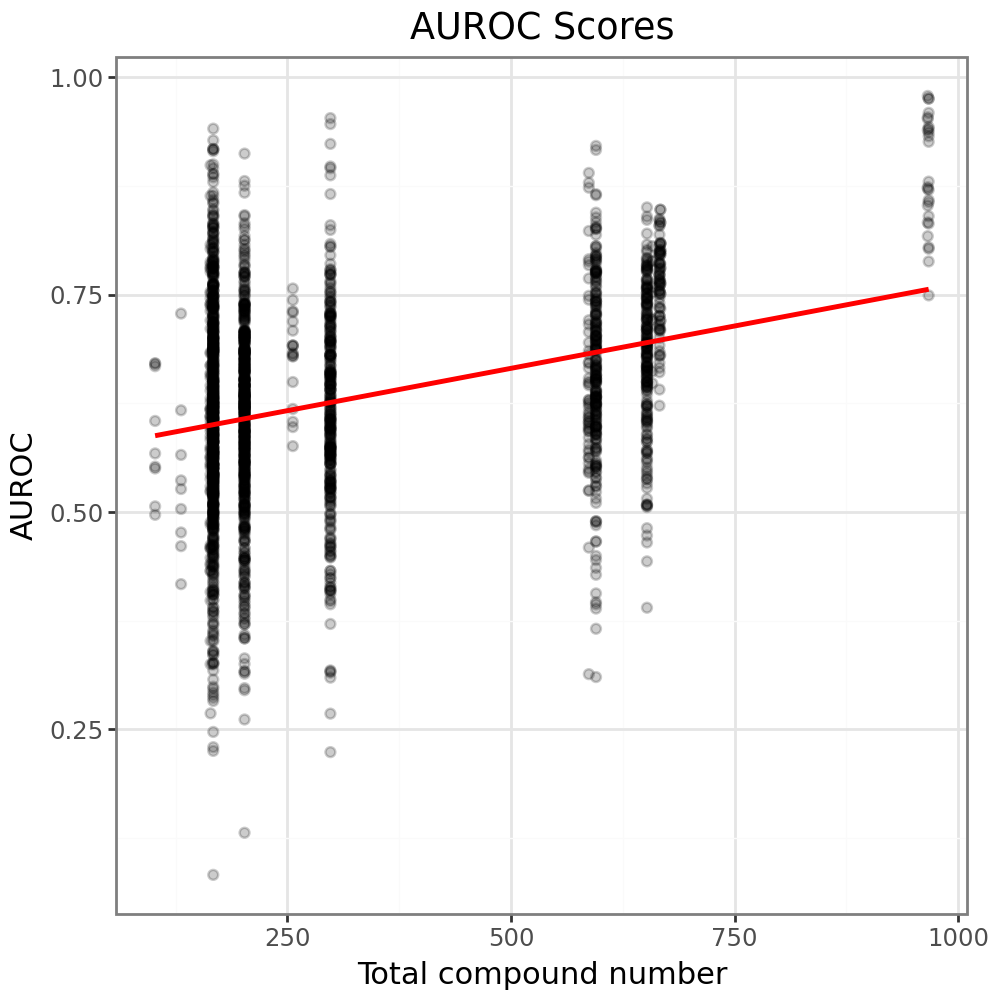

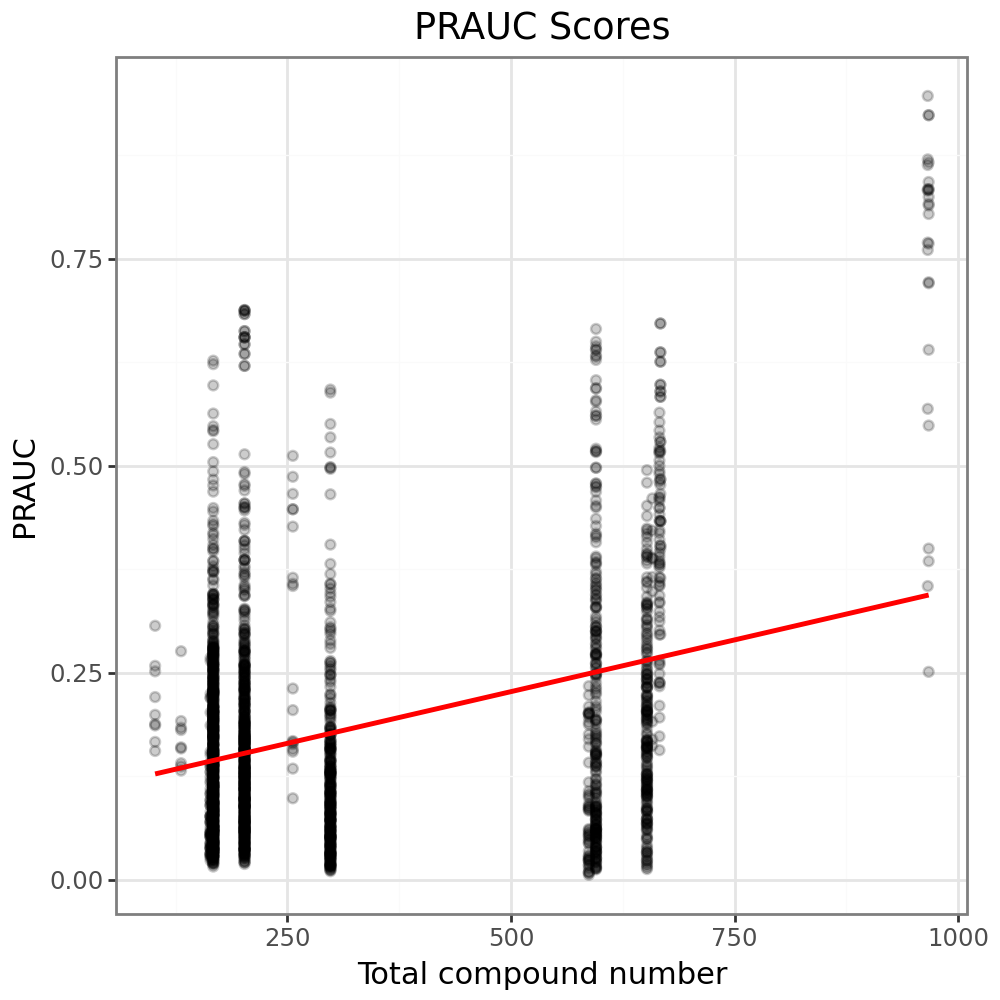

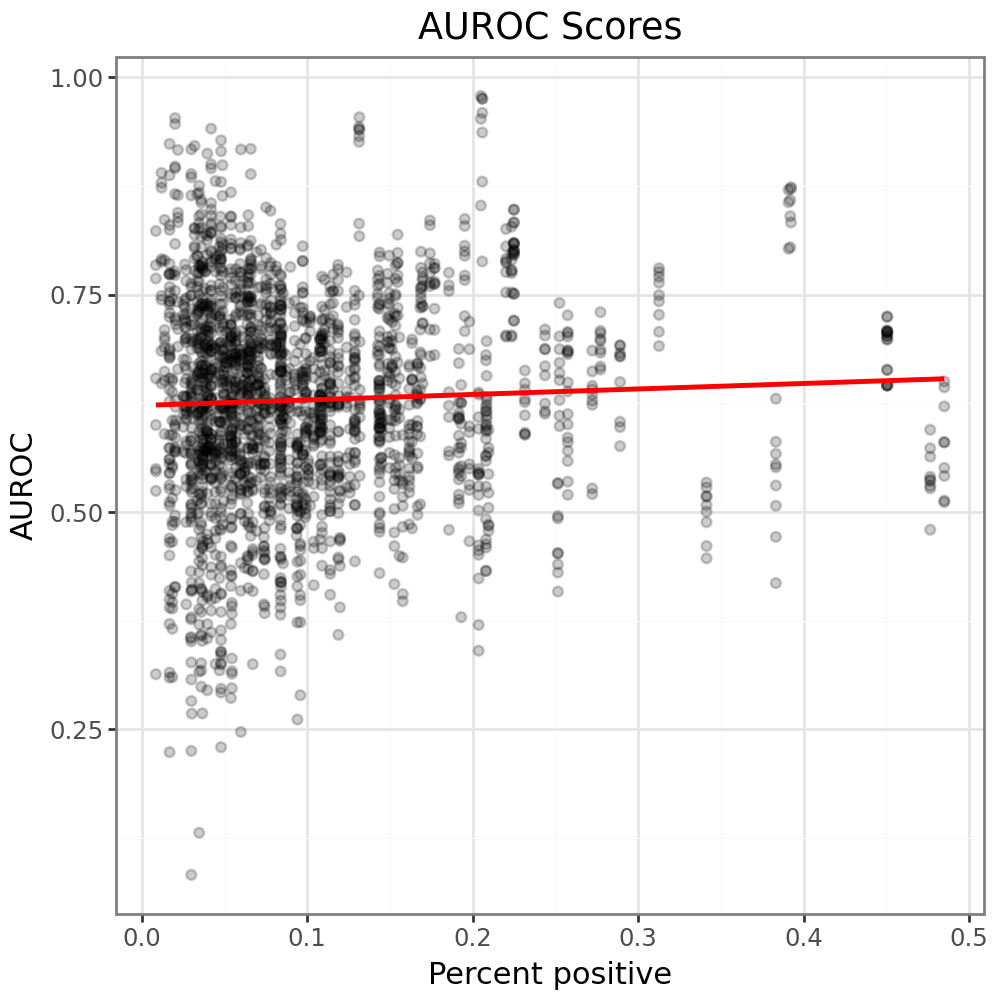

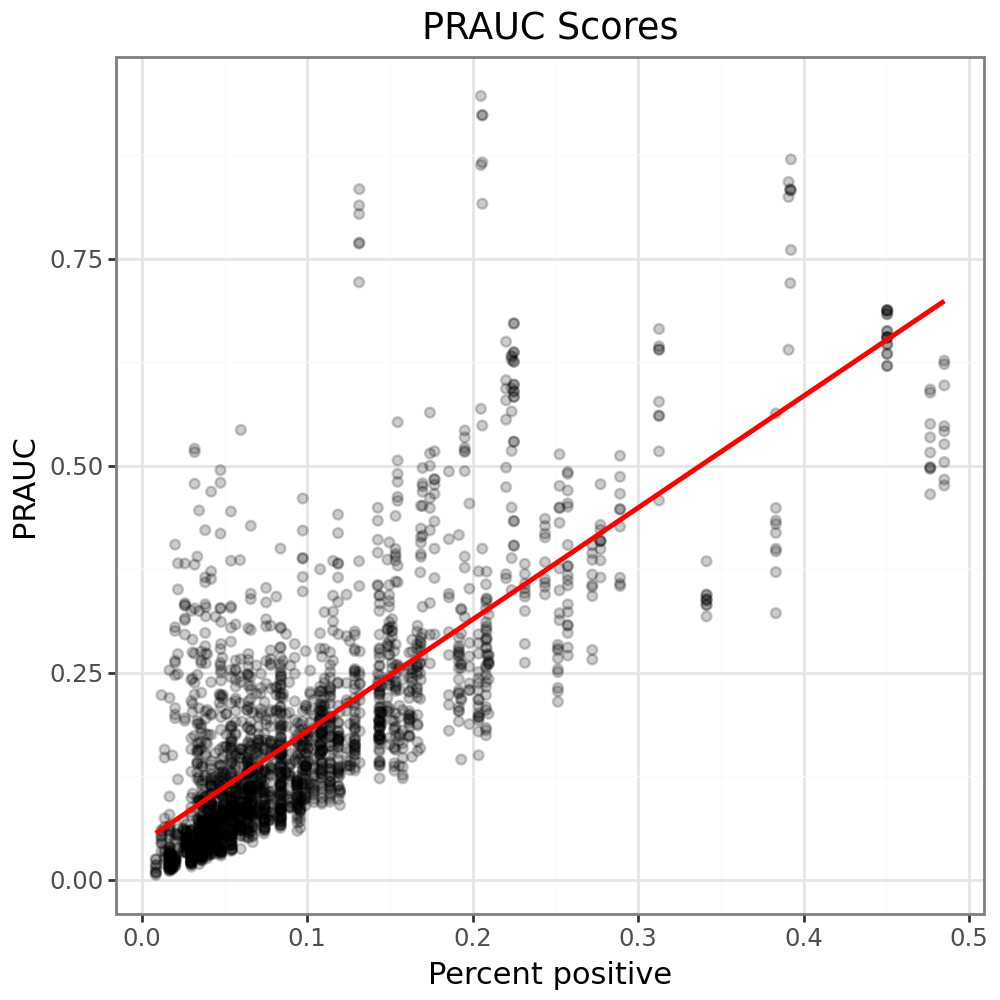

In [10]:
import plotnine as pn
from plotnine import geom_point, ggplot, aes, labs, theme_bw, facet_wrap

pn.options.figure_size = (5, 5)

plot = (
    ggplot(pred_pandas[pred_pandas["Model_type"] == "Actual"], aes(x='Total_Compounds', y='AUROC')) 
    + geom_point(alpha=0.2) 
    + geom_smooth(method='lm', color='red', se=False)
    + labs(title='AUROC Scores', x='Total compound number', y='AUROC') 
    + theme_bw()
)
plot.show()

plot = (
    ggplot(pred_pandas[pred_pandas["Model_type"] == "Actual"], aes(x='Total_Compounds', y='PRAUC')) 
    + geom_point(alpha=0.2) 
    + geom_smooth(method='lm', color='red', se=False)
    + labs(title='PRAUC Scores', x='Total compound number', y='PRAUC') 
    + theme_bw()
)
plot.show()

plot = (
    ggplot(pred_pandas[pred_pandas["Model_type"] == "Actual"], aes(x='Percent_Positive', y='AUROC')) 
    + geom_point(alpha=0.2) 
    + geom_smooth(method='lm', color='red', se=False)
    + labs(title='AUROC Scores', x='Percent positive', y='AUROC') 
    + theme_bw()
)
plot.show()

plot = (
    ggplot(pred_pandas[pred_pandas["Model_type"] == "Actual"], aes(x='Percent_Positive', y='PRAUC')) 
    + geom_point(alpha=0.2) 
    + geom_smooth(method='lm', color='red', se=False)
    + labs(title='PRAUC Scores', x='Percent positive', y='PRAUC') 
    + theme_bw()
)
plot.show()